# Build a retrieval agent with LangGraph

In [2]:
import sys
import os

# Use current working directory and go one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

# Now you can import your config
from config import api_key

from openai import OpenAI

In this tutorial we will build a retrieval agent. Retrieval agents are useful when you want an LLM to make a decision about whether to retrieve context from a vectorstore or respond to the user directly.

By the end of the tutorial we will have done the following:

1. Fetch and preprocess documents that will be used for retrieval.
2. Index those documents for semantic search and create a retriever tool for the agent.
3. Build an agentic RAG system that can decide when to use the retriever tool.

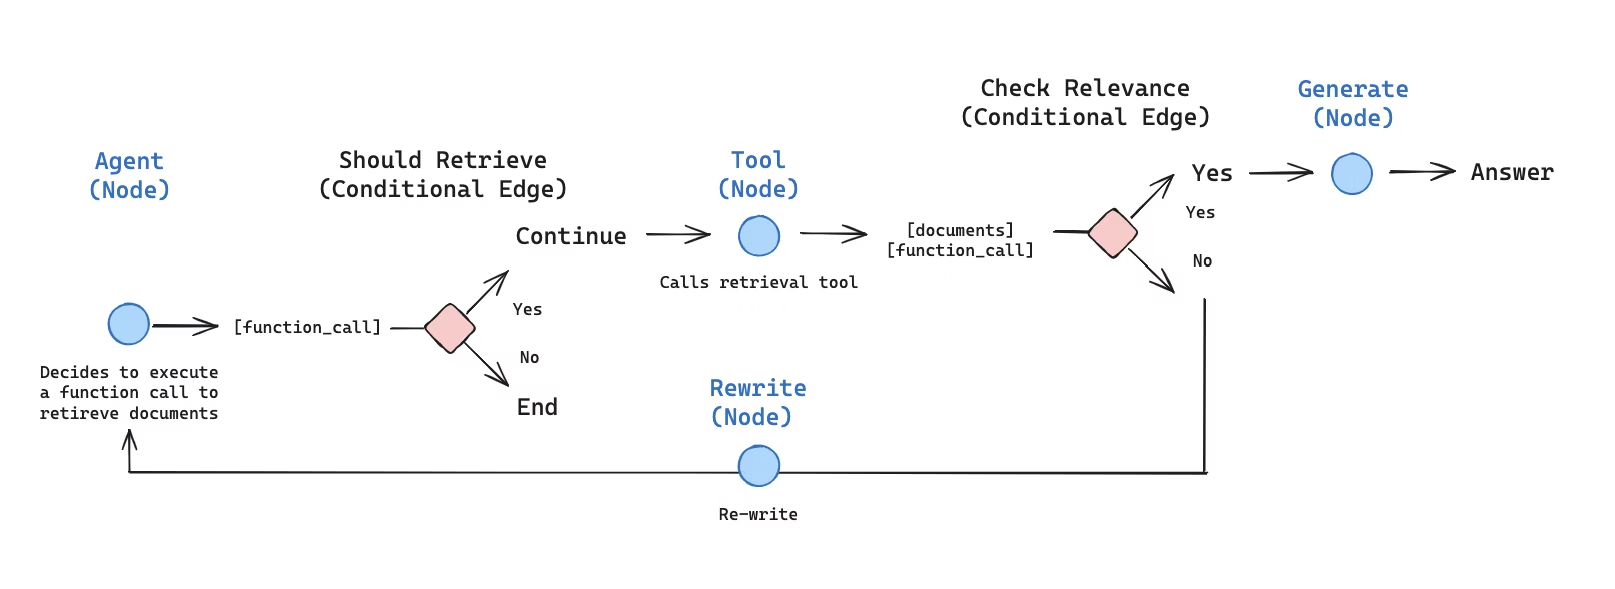

## 1. Preprocess documents

Fetch documents to use in our RAG system. We will use three of the most recent pages from **Lilian Weng’s excellent blog**. We’ll start by fetching the content of the pages using `WebBaseLoader` utility:

In [3]:
from langchain_community.document_loaders import WebBaseLoader

urls = [
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

docs = [WebBaseLoader(url).load() for url in urls]

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
print(f"The number of documents {len(docs)}")
print(f"The number of characters of the first doc {len(docs[0][0].page_content)}")

The number of documents 3
The number of characters of the first doc 51358


In [15]:
docs[0][0].page_content.strip()[:1000]

"Reward Hacking in Reinforcement Learning | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      Reward Hacking in Reinforcement Learning\n    \nDate: November 28, 2024  |  Estimated Reading Time: 37 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nBackground\n\nReward Function in RL\n\nSpurious Correlation\n\n\nLet’s Define Reward Hacking\n\nList of Examples\n\nReward hacking examples in RL tasks\n\nReward hacking examples in LLM tasks\n\nReward hacking examples in real life\n\n\nWhy does Reward Hacking Exist?\n\n\nHacking RL Environment\n\nHacking RLHF of LLMs\n\nHacking the Training Process\n\nHacking the Evaluator\n\nIn-Context Reward Hacking\n\n\nGeneralization of Hacking Skills\n\nPeek into Mitigations\n\nRL Algorithm Improvement\n\nDetecting Reward Hacking\n\nData Analysis of RLHF\

Split the fetched documents into smaller chunks for indexing into our vectorstore:



In [16]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# double list comprehension to get a list with three docs
docs_list = [item for sublist in docs for item in sublist]

# split the text in tokens using from_tiktoken_encoder
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=50
)

doc_splits = text_splitter.split_documents(docs_list)
len(doc_splits)

540

## 2. Create a retriever tool

Now that we have our split documents, we can index them into a vector store that we’ll use for semantic search.

1. Use an in-memory vector store and OpenAI embeddings:

In [22]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

# create an embedding for each chunk in doc_splits and 
# store in the vector database
vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits, embedding=OpenAIEmbeddings(api_key=api_key)
)

# set the retriever to the four best matches (4 is the default)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

In [23]:
result = retriever.invoke("types of reward hacking")

In [24]:
print(f"{len(result)}")
print(result[0])

4
page_content='Detecting Reward Hacking#' metadata={'source': 'https://lilianweng.github.io/posts/2024-11-28-reward-hacking/', 'title': "Reward Hacking in Reinforcement Learning | Lil'Log", 'description': 'Reward hacking occurs when a reinforcement learning (RL) agent exploits flaws or ambiguities in the reward function to achieve high rewards, without genuinely learning or completing the intended task. Reward hacking exists because RL environments are often imperfect, and it is fundamentally challenging to accurately specify a reward function.\nWith the rise of language models generalizing to a broad spectrum of tasks and RLHF becomes a de facto method for alignment training, reward hacking in RL training of language models has become a critical practical challenge. Instances where the model learns to modify unit tests to pass coding tasks, or where responses contain biases that mimic a user’s preference, are pretty concerning and are likely one of the major blockers for real-world d

2. Create a retriever tool using LangChain’s prebuilt `create_retriever_tool`

> **Note** - One can use the retriever to get relevant results. However a tool is needed if we want to build an Agent. 

In [25]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    name="retrieve_blog_posts",
    description= "Search and return information about Lilian Weng blog posts.",
)

3. Test the tool:

In [26]:
retriever_tool.invoke({"query": "types of reward hacking"})

'Detecting Reward Hacking#\n\nIn-Context Reward Hacking#\n\n(Note: Some work defines reward tampering as a distinct category of misalignment behavior from reward hacking. But I consider reward hacking as a broader concept here.)\nAt a high level, reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering.\n\nWhy does Reward Hacking Exist?#'

## 3. Generate query

Now we will start building components (**nodes** and **edges**) for our agentic RAG graph.

Note that the components will operate on the `MessagesState` — graph state that contains a `messages` key with a list of **chat messages**.

Build a `generate_query_or_respond` node. It will call an LLM to generate a response based on the current graph state (list of messages). Given the input messages, it will decide to retrieve using the retriever tool, or respond directly to the user. Note that we’re giving the chat model access to the `retriever_tool` we created earlier via `.bind_tools`:

In [27]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model

# A unified entry point to all llm providers
response_model = init_chat_model("openai:gpt-4.1", temperature=0, api_key=api_key)

def generate_query_or_respond(state: MessagesState):
    """
    Call the model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    response = (
        response_model
        .bind_tools([retriever_tool]).invoke(state["messages"])  
    )
    return {"messages": [response]}

Try it on a random input:

In [28]:
input = {"messages": [{"role": "user", "content": "hello!"}]}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hello! How can I help you today?


Ask a question that requires semantic search:

In [29]:
input = {
    "messages": [
        {
            "role": "user",
            "content": "What does Lilian Weng say about types of reward hacking?",
        }
    ]
}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_w12RnkdpKmrn4Bly5zx1MItG)
 Call ID: call_w12RnkdpKmrn4Bly5zx1MItG
  Args:
    query: types of reward hacking


In [30]:
result = generate_query_or_respond(input)["messages"]

In [31]:
result[0].additional_kwargs

{'tool_calls': [{'id': 'call_MPKyCLKUuQOoQfhPpJGN7SaE',
   'function': {'arguments': '{"query":"types of reward hacking"}',
    'name': 'retrieve_blog_posts'},
   'type': 'function'}],
 'refusal': None}

In [33]:
result[0]

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_MPKyCLKUuQOoQfhPpJGN7SaE', 'function': {'arguments': '{"query":"types of reward hacking"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 72, 'total_tokens': 90, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_62bb2e3c55', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b84a2774-9894-457e-aa0f-2f7e32e9d6d4-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'types of reward hacking'}, 'id': 'call_MPKyCLKUuQOoQfhPpJGN7SaE', 'type': 'tool_call'}], usage_metadata={'input_tokens': 72, 'output_tokens': 18, 'total_tokens': 90, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [36]:
# pretty print works well for all messages types
result[0].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_MPKyCLKUuQOoQfhPpJGN7SaE)
 Call ID: call_MPKyCLKUuQOoQfhPpJGN7SaE
  Args:
    query: types of reward hacking


## 4. Grade documents

Add a **conditional edge** — grade_documents — to determine whether the retrieved documents are relevant to the question. We will use a model with a structured output schema GradeDocuments for document grading. The grade_documents function will return the name of the node to go to based on the grading decision (`generate_answer` or `rewrite_question`):

In [37]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)


class GradeDocuments(BaseModel):  
    """Grade documents using a binary score for relevance check."""

    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )


grader_model = init_chat_model("openai:gpt-4.1", temperature=0, api_key=api_key)


def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    # Please note that we have -1 below. This refers to wat is returned by the 
    # revriever above
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (
        grader_model
        .with_structured_output(GradeDocuments).invoke(  
            [{"role": "user", "content": prompt}]
        )
    )
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

Run this with irrelevant documents in the tool response. For this first a dummy message is constructed that represents a possible state. When this function is called it is assumed that there is a question that is the HumanMessage. This is used by the function. The llm will be called with this message and it the node will decide if a tool is called or not. This response is in the AIMessage (the second message). This is not used in the `grade_document` function (so it should be in the graph part IF if a tool call has been returned). Then based on the second message a the actual python function is executed (here that is a result from the vector database). That is the third message. This is also used in the function.

In [38]:
from langchain_core.messages import convert_to_messages

input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {"role": "tool", "content": "meow", "tool_call_id": "1"},
        ]
    )
}
grade_documents(input)

'rewrite_question'

`convert_to_message` is a nice function that converts a prompt to langchain message so it can be used by `.invoke()`

In [39]:
input

{'messages': [HumanMessage(content='What does Lilian Weng say about types of reward hacking?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'types of reward hacking'}, 'id': '1', 'type': 'tool_call'}]),
  ToolMessage(content='meow', tool_call_id='1')]}

In [40]:
type(input['messages'][0])

langchain_core.messages.human.HumanMessage

Confirm that the relevant documents are classified as such:

In [41]:
# here it is assumed that the last message in he state has context that relates to input question
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}
grade_documents(input)

'generate_answer'

## 5. Rewrite question

Build the `rewrite_question` node. The retriever tool can return potentially irrelevant documents (the `grade_document` function will assess the relevance with an outcome `rewrite_questions` or `generate_answer`), which indicates a need to improve the original user question. To do so, we will call the `rewrite_question` node:

In [43]:
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)


def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content # the question is always first element of messages list
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [{"role": "user", "content": response.content}]}

Try it out:

In [44]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {"role": "tool", "content": "meow", "tool_call_id": "1"},
        ]
    )
}

response = rewrite_question(input)
print(response["messages"][-1]["content"])

Certainly! Here’s an improved version of the question:

**"According to Lilian Weng, what are the different types of reward hacking, and how does she describe them?"**


## 6. Generate an answer

Build `generate_answer` node: if we pass the grader checks, we can generate the final answer based on the original question and the retrieved context:

In [45]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)


def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

Try it:

In [46]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}

response = generate_answer(input)
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Lilian Weng says that reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering. These categories describe different ways in which an agent might exploit flaws in the reward system. Environment or goal misspecification involves unintended behaviors due to poorly specified objectives, while reward tampering involves the agent manipulating the reward signal itself.


## 7. Assemble the graph

- Start with a `generate_query_or_respond` and determine if we need to call `retriever_tool`
- Route to next step using `tools_condition`:
    - If `generate_query_or_respond` returned `tool_calls`, call `retriever_tool` node to retrieve context
    - Otherwise, respond directly to the user
- Grade retrieved document content for relevance to the question (`grade_documents`) and route to next step:
    - If not relevant, rewrite the question using `rewrite_question` and then call `generate_query_or_respond` again
    - If relevant, proceed to `generate_answer` and generate final response using the `ToolMessage` with the retrieved document context

In [47]:
from langgraph.graph import StateGraph, START, END
from langgraph. prebuilt import ToolNode, tools_condition

In [48]:
workflow = StateGraph(MessagesState)

# Define the nodes we will cycle between
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retriever_tool]))
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

workflow.add_edge(START, "generate_query_or_respond")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "generate_query_or_respond",
    # Assess LLM decision (call `retriever_tool` tool or respond to the user)
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Compile
graph = workflow.compile()

>  **Note**: the second `.add_conditional_edge` here you do not define the route as the output of grade_documents returns either `rewrite_question` or `generate_answer`. These are names of nodes in the graph. So it knows where to go based on the outcome.

>  **Note**: also note that there can potentially be several iterations through the graph (from `rewrite_question` you might be redirected to the `generate_query_or_respond` note.

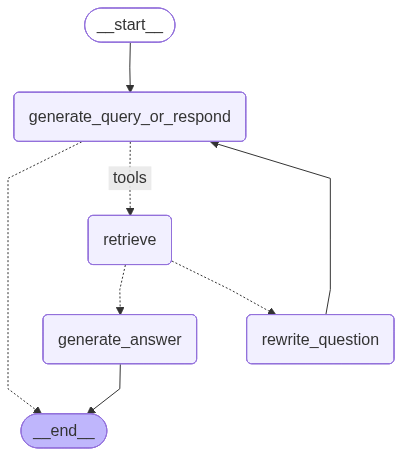

In [50]:
graph

## 8. Run the agentic RAG

In [51]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_JUqhwqJ0BQMGEF8OkgkWIVQu)
 Call ID: call_JUqhwqJ0BQMGEF8OkgkWIVQu
  Args:
    query: types of reward hacking



Update from node retrieve
================================= Tool Message =================================
Name: retrieve_blog_posts

Detecting Reward Hacking#

In-Context Reward Hacking#

(Note: Some work defines reward tampering as a distinct category of misalignment behavior from reward hacking. But I consider reward hacking as a broader concept here.)
At a high level, reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering.

Why does Reward Hacking Exist?#



Update from node generate_answer
================================== Ai Message ==================================

Lilian Weng categorizes reward hacking into two types: environment or goal misspecificat

In [52]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is the time?",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================

The current time is 2024-07-01 13:36:13 UTC. If you need the time in a specific timezone, please let me know!





In [53]:
messages =     {
        "messages": [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            }
        ]
    }

result = graph.invoke(messages)

In [54]:
# result contains the history of messages but does not store it in memory
len(result['messages'])

4